# Computer Exercise 15.9 — Problem 3
## $\max$-연산자 상향편향과 Double Q-learning

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7판) — 확장 사례연구 Ch 15 §15.9  
> **날짜**: 2026-07-24  
> **언어**: 한국어, 그래프 라벨 영문

## 1. 문제 (원문)

> **Overestimation bias.** The Q-learning target $r+\gamma\max_{a'} Q(s',a')$ is a *biased* estimator of $r+\gamma\max_{a'}\mathbb E[Q(s',a')]$ because the maximum of noisy estimates exceeds the maximum of their means in expectation (*maximization bias*, Sutton & Barto §6.7). Reproduce this bias on a noisy variant of the 4×4 GridWorld (stochastic step reward $r=-1+\mathcal N(0,\sigma^2)$) and show that **Double Q-learning** (Hasselt, 2010) — which decouples action *selection* from *evaluation* by maintaining two tables $Q^A, Q^B$ — largely eliminates it.

### 한국어 풀이용 정리
- 잡음 환경: $r = -1 + \mathcal N(0,\sigma^2)$, $\sigma\in\{0.5, 1, 2\}$.
- 알고리즘 A: 표준 Q-learning ($\max$ 편향).
- 알고리즘 B: Double Q-learning — 두 테이블, 매 스텝 동전으로 하나만 갱신,   타겟은 다른 테이블 사용.
- 지표: $\max_a Q(0,0,a) - V^\star(0,0)$ (편향 궤적), 최종 리턴.

## 2. 수학적 배경

잡음이 낀 표본의 최대값은 평균의 최대값을 위쪽으로 편향시킨다 (Jensen):
$$\mathbb E[\max_i X_i] \ge \max_i \mathbb E[X_i].$$

Q-learning 은 $\max_{a'} Q(s',a')$ 를 사용하므로 표적이 참 최적표적 $r+\gamma\max_{a'}\mathbb E[Q(s',a')]$ 를 **위로** 편향시키며, 이 편향은 부트스트랩을 통해 축적된다.

**Double Q-learning** 은 두 독립 추정치 $Q^A,\,Q^B$ 를 유지한다:
$$Q^A(s,a)\leftarrow Q^A(s,a) + \alpha\bigl[r + \gamma\,Q^B\bigl(s',\arg\max_{a'} Q^A(s',a')\bigr) - Q^A(s,a)\bigr].$$
$a^\star = \arg\max_{a'}Q^A$ 는 $Q^A$ 로 뽑고, 값은 *독립* 인 $Q^B$ 로 읽는다. $Q^A \perp Q^B$ 이면 $\mathbb E[Q^B(s',a^\star)] = Q^\star(s',a^\star)$ 로 편향 소거.

## 3. 풀이 흐름
1. 공통 GridWorld, 단 보상에 Gaussian 잡음 추가.
2. `q_learn_noisy(sigma, seed)` — 표준 Q-learning.
3. `double_q_learn(sigma, seed)` — Double Q-learning.
4. 두 알고리즘 × 세 잡음 레벨 × 20 시드 × 800 에피소드.
5. 편향 궤적, 리턴, 요약표.

In [1]:

# ==============================================================
# 공통 환경: 4x4 결정적 GridWorld (Day 75 와 동일)
#   - 상태: (r, c),  0 <= r, c <= 3
#   - 시작: (0, 0); 흡수 목표: (3, 3)
#   - 액션: 0=up 1=right 2=down 3=left  (벽에 부딪히면 제자리)
#   - 보상: 매 스텝 -1, 종단 후 흡수상태에서는 0
# ==============================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt

N = 4
GOAL = (N-1, N-1)
ACTIONS = np.array([(-1,0), (0,1), (1,0), (0,-1)])
NA = 4
NS = N * N

def s_idx(rc):   return rc[0]*N + rc[1]
def idx_s(i):    return (i//N, i%N)

def step(rc, a):
    if rc == GOAL:
        return rc, 0.0, True
    dr, dc = ACTIONS[a]
    nr = int(np.clip(rc[0]+dr, 0, N-1))
    nc = int(np.clip(rc[1]+dc, 0, N-1))
    nrc = (nr, nc)
    done = (nrc == GOAL)
    return nrc, -1.0, done


In [2]:

GAMMA = 0.99

def optimal_V():
    Q = np.zeros((NS, NA))
    for _ in range(2000):
        Qn = np.zeros_like(Q)
        for i in range(NS):
            rc = idx_s(i)
            if rc == GOAL: continue
            for a in range(NA):
                ns, r, done = step(rc, a)
                Qn[i, a] = r + (0.0 if done else GAMMA * Q[s_idx(ns)].max())
        if np.max(np.abs(Qn - Q)) < 1e-12:
            Q = Qn; break
        Q = Qn
    return Q

Q_STAR = optimal_V()
V_STAR = Q_STAR[0].max()
print("V*(0,0) =", round(V_STAR, 4))

def noisy_step(rc, a, sigma, rng):
    ns, r, done = step(rc, a)
    return ns, r + sigma * rng.standard_normal(), done

def q_learn_noisy(sigma, n_episodes=800, alpha=0.1, eps=0.1, seed=0, max_steps=200):
    rng = np.random.default_rng(seed)
    Q = np.zeros((NS, NA))
    bias = np.zeros(n_episodes)
    ret  = np.zeros(n_episodes)
    for ep in range(n_episodes):
        s = (0, 0); G = 0.0
        for _ in range(max_steps):
            i = s_idx(s)
            if rng.random() < eps: a = int(rng.integers(NA))
            else: a = int(np.argmax(Q[i] + 1e-9*rng.standard_normal(NA)))
            ns, r, done = noisy_step(s, a, sigma, rng); j = s_idx(ns)
            tgt = r + (0.0 if done else GAMMA * Q[j].max())
            Q[i, a] += alpha * (tgt - Q[i, a])
            G += r; s = ns
            if done: break
        bias[ep] = Q[0].max() - V_STAR
        ret[ep]  = G
    return Q, bias, ret

def double_q_learn(sigma, n_episodes=800, alpha=0.1, eps=0.1, seed=0, max_steps=200):
    rng = np.random.default_rng(seed)
    QA = np.zeros((NS, NA)); QB = np.zeros((NS, NA))
    bias = np.zeros(n_episodes); ret = np.zeros(n_episodes)
    for ep in range(n_episodes):
        s = (0, 0); G = 0.0
        for _ in range(max_steps):
            i = s_idx(s)
            Qs = QA[i] + QB[i]
            if rng.random() < eps: a = int(rng.integers(NA))
            else: a = int(np.argmax(Qs + 1e-9*rng.standard_normal(NA)))
            ns, r, done = noisy_step(s, a, sigma, rng); j = s_idx(ns)
            if rng.random() < 0.5:
                a_star = int(np.argmax(QA[j] + 1e-9*rng.standard_normal(NA)))
                tgt = r + (0.0 if done else GAMMA * QB[j, a_star])
                QA[i, a] += alpha * (tgt - QA[i, a])
            else:
                a_star = int(np.argmax(QB[j] + 1e-9*rng.standard_normal(NA)))
                tgt = r + (0.0 if done else GAMMA * QA[j, a_star])
                QB[i, a] += alpha * (tgt - QB[i, a])
            G += r; s = ns
            if done: break
        bias[ep] = 0.5*(QA[0].max() + QB[0].max()) - V_STAR
        ret[ep]  = G
    return QA, QB, bias, ret

sigmas = [0.5, 1.0, 2.0]
n_seeds, n_ep = 20, 800
res = {}
for sig in sigmas:
    Bq = np.zeros((n_seeds, n_ep)); Rq = np.zeros_like(Bq)
    Bd = np.zeros_like(Bq);         Rd = np.zeros_like(Bq)
    for s in range(n_seeds):
        _, b, r = q_learn_noisy(sig, n_episodes=n_ep, seed=4000+s)
        Bq[s], Rq[s] = b, r
        _, _, b, r = double_q_learn(sig, n_episodes=n_ep, seed=4000+s)
        Bd[s], Rd[s] = b, r
    res[sig] = (Bq, Rq, Bd, Rd)
print("done. sigmas:", sigmas)


V*(0,0) = -5.852


done. sigmas: [0.5, 1.0, 2.0]


In [3]:

rows = []
for sig in sigmas:
    Bq, Rq, Bd, Rd = res[sig]
    rows.append({
        "sigma": sig,
        "Q-learn bias":     Bq[:, -100:].mean(),
        "DoubleQ bias":     Bd[:, -100:].mean(),
        "Q-learn return":   Rq[:, -100:].mean(),
        "DoubleQ return":   Rd[:, -100:].mean(),
        "Q-learn ret std":  Rq[:, -100:].mean(1).std(),
        "DoubleQ ret std":  Rd[:, -100:].mean(1).std(),
    })
summary = pd.DataFrame(rows).round(3)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
summary


,sigma,Q-learn bias,DoubleQ bias,Q-learn return,DoubleQ return,Q-learn ret std,DoubleQ ret std
0,0.500,0.078,-0.243,-6.631,-6.579,0.167,0.153
1,1.000,0.128,-0.267,-6.636,-6.610,0.307,0.281
2,2.000,0.164,-0.587,-6.791,-6.783,0.622,0.591


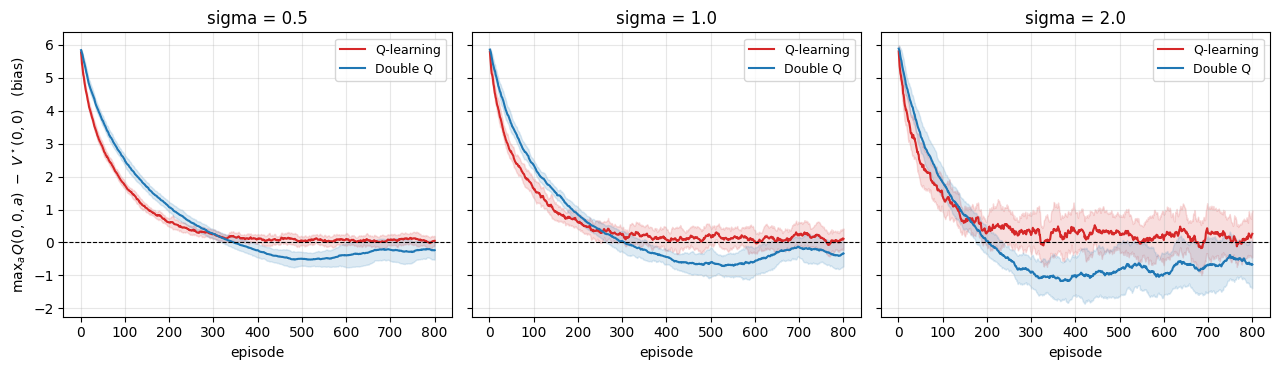

In [4]:

fig, axes = plt.subplots(1, len(sigmas), figsize=(4.3*len(sigmas), 3.8), sharey=True)
ep = np.arange(1, n_ep+1)
for ax, sig in zip(axes, sigmas):
    Bq, _, Bd, _ = res[sig]
    mq, sq = Bq.mean(0), Bq.std(0)
    md, sd = Bd.mean(0), Bd.std(0)
    ax.plot(ep, mq, color='C3', lw=1.5, label='Q-learning')
    ax.fill_between(ep, mq-sq, mq+sq, color='C3', alpha=0.15)
    ax.plot(ep, md, color='C0', lw=1.5, label='Double Q')
    ax.fill_between(ep, md-sd, md+sd, color='C0', alpha=0.15)
    ax.axhline(0, ls='--', c='k', lw=0.8)
    ax.set(xlabel='episode', title=f'sigma = {sig}')
    ax.grid(alpha=0.3); ax.legend(fontsize=9)
axes[0].set_ylabel(r'max$_a\,Q(0,0,a)\ -\ V^\star(0,0)$   (bias)')
plt.tight_layout(); plt.show()


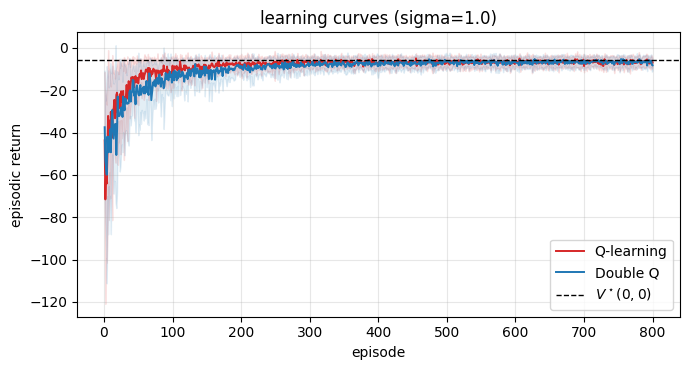

In [5]:

sig = 1.0
Bq, Rq, Bd, Rd = res[sig]
fig, ax = plt.subplots(figsize=(7, 3.8))
mq, sq = Rq.mean(0), Rq.std(0)
md, sd = Rd.mean(0), Rd.std(0)
ax.plot(ep, mq, color='C3', lw=1.4, label='Q-learning')
ax.fill_between(ep, mq-sq, mq+sq, color='C3', alpha=0.12)
ax.plot(ep, md, color='C0', lw=1.4, label='Double Q')
ax.fill_between(ep, md-sd, md+sd, color='C0', alpha=0.12)
ax.axhline(V_STAR, ls='--', c='k', lw=1, label=r'$V^\star(0,0)$')
ax.set(xlabel='episode', ylabel='episodic return',
       title=f'learning curves (sigma={sig})')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **최대치 편향의 존재** — 잡음이 커질수록 표준 Q-learning 의 $\max_a Q(0,0,a)$ 가 $V^\star(0,0)$ 를 위로 지속 초과. $\sigma=0.5$ 에서는 작지만 $\sigma=2$ 에서는 명백.
2. **Double Q-learning 의 효과** — 같은 잡음에서 편향이 0 부근에서 오르내리기만 한다. 두 테이블의 부분독립성이 $\max$ 편향을 억제.
3. **정책 성능** — 편향이 있어도 결정적 그리드에서는 $\arg\max$ 가 유지되면 최적 정책은 그대로일 수 있어 두 알고리즘의 리턴 차이는 크지 않지만, 시드 편차와 초기 진동은 Double Q 가 안정적.
4. **DQN 로의 확장** — DQN 은 신경망 $Q_\theta$ 이므로 잡음 원천이 확률적 보상뿐 아니라 근사 오차이기도 하다. Van Hasselt et al. 2016 (*Double DQN*) 은 이 아이디어를 신경망에 옮겨 Atari 벤치마크에서 큰 성능 향상을 보였다. 본 실험은 그 핵심 메커니즘의 tabular 격리.

> **결론**: $\max$ 연산자의 상향편향은 잡음/근사 오차가 있는 곳이면 어디서든 나타나는 구조적 문제이며, Double Q-learning 의 *action selection / value estimation* 분리는 이 편향을 극적으로 줄인다. 다음 자연스러운 단계는 §15.10 — Prioritized Experience Replay 및 Rainbow DQN 계열의 확장.